In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, FunctionTransformer, StandardScaler
import tensorflow as tf
from tensorflow.keras import  regularizers, callbacks
from tensorflow.python.keras.utils.vis_utils import plot_model
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Input, Dropout, Concatenate, LeakyReLU, BatchNormalization, Activation
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint, Callback

# tf-explain for visual explanations
from tf_explain.core.gradients_inputs import GradientsInputs


from scipy.stats import norm
from scipy import stats
import lime
from lime.lime_tabular import LimeTabularExplainer
from interpret.blackbox import LimeTabular
from interpret import show

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from sklearn.metrics import (classification_report, accuracy_score, f1_score, balanced_accuracy_score,
roc_auc_score, confusion_matrix, roc_curve, auc, precision_recall_curve, average_precision_score, matthews_corrcoef)
from sklearn.preprocessing import label_binarize
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA
import shap

In [2]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

In [3]:
# load the dataset
df = pd.read_csv("./dataset_for_classification_model.csv")
df

,seq_sample_id,age,BMI,category,sequencing_depth,volume,TSPAN6,DPM1,SCYL3,CFH,...,ENSG00000309174,ENSG00000309618,ENSG00000310376,CAST,ENSG00000310523,WASH7P,WASH9P,ENSG00000310533,sex_female,sex_male
0,FP11w0L,22.3,23.6,No_responder,1.51,1,3.85,30.23,8.50,15.33,...,2.95,5.89,1125.84,230.96,5.93,11.60,5.07,1.88,0,1
1,FP11w0R,22.3,23.6,No_responder,1.51,3,4.72,27.63,9.59,19.16,...,3.75,4.72,1057.75,243.95,5.91,11.36,3.96,2.30,0,1
2,FP12w0L,21.3,22.8,No_responder,1.51,1,5.48,32.51,6.23,15.13,...,2.91,7.09,614.65,143.06,7.21,7.53,7.33,2.78,1,0
3,FP12w0R,21.3,22.8,No_responder,1.51,3,5.88,28.35,5.72,16.30,...,2.41,10.94,584.76,142.61,7.23,15.26,9.02,1.10,1,0
4,FP13w0L,22.7,19.8,High_responder,1.51,3,5.59,34.57,4.74,9.17,...,2.29,6.95,724.77,158.42,3.87,16.90,13.56,5.87,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
456,s891,54.0,21.8,Average_responder,2.35,3,3.94,18.93,7.06,10.28,...,4.78,1.79,12.13,131.02,17.86,29.32,28.00,3.93,1,0
457,s903,42.0,27.3,High_responder,2.35,3,4.37,18.69,7.91,15.64,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
458,s903,42.0,27.3,Average_responder,2.35,3,4.37,18.69,7.91,15.64,...,3.86,2.01,12.21,126.66,13.64,27.64,18.58,1.20,1,0
459,s96,48.0,27.7,Average_responder,2.35,3,4.69,25.65,7.67,13.27,...,1.94,1.73,37.61,151.40,15.83,24.10,27.72,3.25,0,1


## Create predictor and response variables

In [4]:
X = df.drop(["seq_sample_id", "category"], axis = 1) # drop sample_id and category columns

y = df["category"] # response variable
category_mapping = {'No_responder': 0, 'Average_responder': 1, 'High_responder': 2} # label encode the variables
y = y.map(category_mapping)
y

0      0
1      0
2      0
3      0
4      2
      ..
456    1
457    2
458    1
459    1
460    1
Name: category, Length: 461, dtype: int64

Data splitting and scaling

In [5]:
# create the final test set (20% of data) which we won't touch until the very end.
X_train_full, X_test, y_train_full, y_test = train_test_split( X, y,  test_size=0.2, random_state=RANDOM_STATE, stratify = y)
# "stratify" ensures that the data distribution is maintained

# Create a validation set (20% of the remaining training data) for monitoring during training.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,  test_size=0.2, random_state=RANDOM_STATE, stratify = y_train_full
)


#  scale the data. Fit the scaler ONLY on the training data to prevent data leakage.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Training feature shape: {X_train_scaled.shape}")
print(f"Validation feature shape: {X_val_scaled.shape}")
print(f"Test feature shape: {X_test_scaled.shape}")

Training feature shape: (294, 11231)
Validation feature shape: (74, 11231)
Test feature shape: (93, 11231)


Model trained on the raw data performed poorly when predicting the high and no responders, hence the decision to use SMOTE (Synthetic Minority Over-sampling Technique) to address the imbalance. SMOTE was applied  on training data alone so as not to force a perfect balance in the dataset  (to reduce overfitting) and also to have an unbiased evaluation of model performance. The minority classes (high_responders, and no_responders) in the training data were oversampled to 80% of average responders.

In [6]:
# Inspect class distribution on training data
classes, counts = np.unique(y_train, return_counts=True)
print("Train class counts:", dict(zip(classes, counts)))

# Target "soft" balancing: bring minorities up to ~80% of the majority in the training split
majority_count = counts.max()
target_level = int(0.8 * majority_count)

# Build a dict for sampling_strategy for multiclass
sampling_strategy = {int(c): min(target_level, int(majority_count)) for c in classes}
# oversample minorities that are below target_level
for c, cnt in zip(classes, counts):
    if cnt >= target_level:
        sampling_strategy[int(c)] = cnt  # keep as is

# k_neighbors must be < minority count; pick conservatively
min_class_count = counts.min()
k_neighbors = max(1, min(5, min_class_count - 1))

print("SMOTE sampling_strategy:", sampling_strategy)
print("SMOTE k_neighbors:", k_neighbors)

smote = SMOTE(
    sampling_strategy=sampling_strategy,
    k_neighbors=k_neighbors,
    random_state=42,
    n_jobs=-1
)

X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)
print("After SMOTE:", {int(c): int(n) for c, n in zip(*np.unique(y_train_sm, return_counts=True))})

Train class counts: {0: 52, 1: 209, 2: 33}
SMOTE sampling_strategy: {0: 167, 1: 209, 2: 167}
SMOTE k_neighbors: 5


C:\Users\chidimmpe\AppData\Local\anaconda\Lib\site-packages\imblearn\over_sampling\_smote\base.py:370: FutureWarning: The parameter `n_jobs` has been deprecated in 0.10 and will be removed in 0.12. You can pass an nearest neighbors estimator where `n_jobs` is already set instead.
  warnings.warn(


After SMOTE: {0: 167, 1: 209, 2: 167}


Text(0, 0.5, 'Frequency')

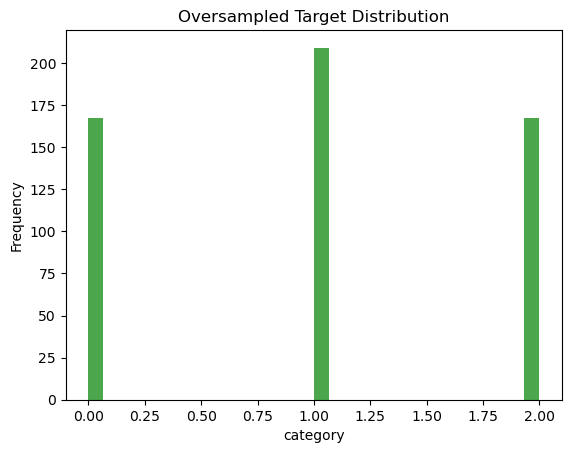

In [7]:
# Step 4: Visualize class distribution after SMOTE
plt.hist(y_train_sm, bins=30, color='green', alpha=0.7)
plt.title('Oversampled Target Distribution')
plt.xlabel('category')
plt.ylabel('Frequency')

Text(0, 0.5, 'Frequency')

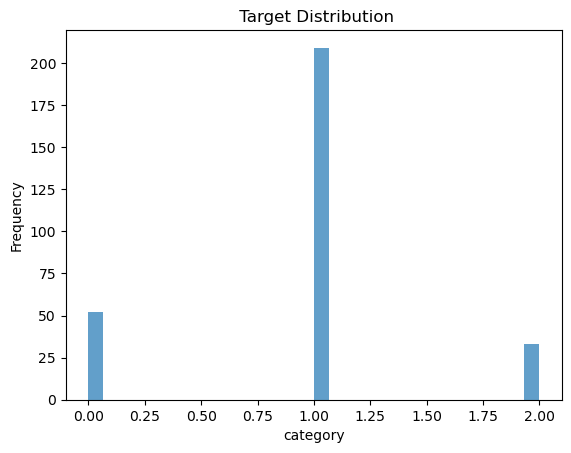

In [8]:
plt.hist(y_train, bins=30, alpha=0.7)
plt.title(' Target Distribution')
plt.xlabel('category')
plt.ylabel('Frequency')

In [9]:
def build_multiclass_model(input_shape, num_classes):
    """Builds a sequential model for multi-class classification."""
    model = Sequential([
        Input(shape=input_shape),
 # Hidden Layer 1: Funnel architecture starts wider. L2 regularization added.
      
      Dense(1024,  kernel_regularizer=regularizers.l2(1e-6)),
        BatchNormalization(), 
       Activation('relu'),
       Dropout(0.5), # Using a slightly higher dropout rate
        
        
        # Hidden Layer 2
       Dense(512, kernel_regularizer=regularizers.l2(1e-5)),
        BatchNormalization(), 
       Activation('relu'),
        Dropout(0.4), # Using a slightly higher dropout rate

        
        # Hidden Layer 3
      Dense(256,  kernel_regularizer=regularizers.l2(1e-4)),
        BatchNormalization(),
        Activation('relu'),
       Dropout(0.3),

        # Hidden Layer 4
        Dense(128,  kernel_regularizer=regularizers.l2(1e-3)),
      #  BatchNormalization(),
       Activation('relu'),
       # Dropout(0.3),
        
         # Hidden Layer 5
        Dense(64,  kernel_regularizer=regularizers.l2(5e-2)),
         Activation('relu'),
        Dense(num_classes, activation='softmax')  # Multi-class classification
    ])
    
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits = False),  # cos labels are encoded as integers
                  metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")])
    
    return model

## Model building

In [10]:
# Get the input shape from the training data
input_shape = (X_train_sm.shape[1],)
model = build_multiclass_model(input_shape, 3)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 1024)                │      11,501,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1024)                │           4,096 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 12,206,211 (46.56 MB)

 Trainable params: 12,202,627 (46.55 MB)

 Non-trainable params: 3,584 (14.00 KB)

In [11]:


class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weight_dict = dict(enumerate(class_weights))



In [12]:
#class ValMCC(tf.keras.callbacks.Callback):
 #   def __init__(self, Xv, yv, name='val_mcc'):
 #       super().__init__(); self.Xv, self.yv, self.name = Xv, yv, name
#    def on_epoch_end(self, epoch, logs=None):
#        y_prob = self.model.predict(self.Xv, verbose=0)
#        y_pred = y_prob.argmax(axis=1)
#        mcc = matthews_corrcoef(self.yv, y_pred)
#        logs[self.name] = mcc
#        print(f" — {self.name}: {mcc:.4f}")

#val_mcc_cb = ValMCC(X_val_scaled, y_val)

# Example: monitor MCC (in addition to macro-F1)
#early_stopping_mcc = EarlyStopping(monitor='val_mcc', mode='max', patience=12, restore_best_weights=True, min_delta=0.002, verbose=1)
#ckpt_mcc = ModelCheckpoint("best_model_mcc.keras", monitor="val_mcc", mode="max", save_best_only=True, verbose=1)





In [13]:


class ValMacroF1(Callback):
    def __init__(self, Xv, yv, name='val_macro_f1'):
        super().__init__(); self.Xv, self.yv, self.name = Xv, yv, name
    def on_epoch_end(self, epoch, logs=None):
        y_prob = self.model.predict(self.Xv, verbose=0)
        y_pred = y_prob.argmax(axis=1)
        macro_f1 = f1_score(self.yv, y_pred, average='macro')
        logs[self.name] = macro_f1
        print(f" — {self.name}: {macro_f1:.4f}")

 
val_macro_f1_cb = ValMacroF1(X_val_scaled, y_val) # macro F1 score gives equal weight to each class in imbalanced datasets

early_stopping = EarlyStopping(
    monitor='val_macro_f1', 
    mode='max',
    patience=12, restore_best_weights=True, verbose=1,
    min_delta = 0.002 # only react to improvesments at or above 0.002
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_macro_f1', mode = "max",  factor=0.5, patience=3,
    min_lr=1e-5, verbose=1,
     min_delta = 0.002 
)

ckpt = ModelCheckpoint("best_smote_model.keras", monitor="val_macro_f1", mode="max",
                       save_best_only=True, verbose=1)

history = model.fit(
    X_train_sm, y_train_sm,  # or X_train_scaled, y_train if using class weights
    validation_data=(X_val_scaled, y_val),
    epochs=200,
    callbacks=[val_macro_f1_cb, 
               early_stopping, 
               reduce_lr, ckpt],
    verbose=1,
  #  class_weight = class_weight_dict
)


Epoch 1/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.3467 - loss: 5.6730 — val_macro_f1: 0.3479

Epoch 1: val_macro_f1 improved from None to 0.34788, saving model to best_smote_model.keras
17/17 ━━━━━━━━━━━━━━━━━━━━ 6s 165ms/step - accuracy: 0.3702 - loss: 5.5671 - val_accuracy: 0.5270 - val_loss: 5.4111 - val_macro_f1: 0.3479 - learning_rate: 3.0000e-04
Epoch 2/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.4954 - loss: 5.1884 — val_macro_f1: 0.2333

Epoch 2: val_macro_f1 did not improve from 0.34788
17/17 ━━━━━━━━━━━━━━━━━━━━ 5s 149ms/step - accuracy: 0.5322 - loss: 5.1082 - val_accuracy: 0.3243 - val_loss: 5.3967 - val_macro_f1: 0.2333 - learning_rate: 3.0000e-04
Epoch 3/200
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.5506 - loss: 4.8667 — val_macro_f1: 0.2333

Epoch 3: val_macro_f1 did not improve from 0.34788
17/17 ━━━━━━━━━━━━━━━━━━━━ 2s 93ms/step - accuracy: 0.5617 - loss: 4.8035 - val_accuracy: 0.3243 - val_loss: 5.1859 - val_macro_f1: 0.2333 

## Explainability using shap

In [14]:
# 1) Load best checkpoint
best_model = tf.keras.models.load_model("best_smote_model.keras")

# 2) Predict validation & test probabilities
y_val_prob  = best_model.predict(X_val_scaled,  verbose=0)
y_test_prob = best_model.predict(X_test_scaled, verbose=0)

y_val_pred_argmax  = np.argmax(y_val_prob,  axis=1)
y_test_pred_argmax = np.argmax(y_test_prob, axis=1)

print("=== Argmax Baseline ===")
print("Validation Macro-F1:", f1_score(y_val, y_val_pred_argmax, average='macro', zero_division=0))
print("Validation MCC:", matthews_corrcoef(y_val, y_val_pred_argmax))
print("Test Macro-F1:", f1_score(y_test, y_test_pred_argmax, average='macro', zero_division=0))
print("Test MCC:", matthews_corrcoef(y_test, y_test_pred_argmax))

# 3) Threshold tuning helpers
def predict_with_thresholds(y_prob, thresholds):
    excess = y_prob - thresholds[None, :]
    fallback = np.argmax(y_prob, axis=1)
    chosen = np.argmax(excess, axis=1)
    below = (excess.max(axis=1) < 0)
    chosen[below] = fallback[below]
    return chosen
def tune_thresholds(y_true, y_prob, metric='macro_f1', grid=np.linspace(0.1, 0.9, 33), max_passes=3):
    K = y_prob.shape[1]
    thr = np.full(K, 1.0 / K, dtype=float)
    def score(y_pred):
        return (matthews_corrcoef(y_true, y_pred) if metric=='mcc'
                else f1_score(y_true, y_pred, average='macro', zero_division=0))
    best_score = -1.0
    for _ in range(max_passes):
        improved = False
        for k in range(K):
            best_k_t, best_k_s = thr[k], best_score
            for t in grid:
                thr_try = thr.copy(); thr_try[k] = t
                sc = score(predict_with_thresholds(y_prob, thr_try))
                if sc > best_k_s:
                    best_k_t, best_k_s = t, sc
            if best_k_s > best_score + 1e-7:
                thr[k], best_score, improved = best_k_t, best_k_s, True
        if not improved:
            break
    return thr, best_score

# 4) Tune on validation, then apply to test
thr_f1,  f1_val  = tune_thresholds(y_val, y_val_prob,  metric='macro_f1')
thr_mcc, mcc_val = tune_thresholds(y_val, y_val_prob,  metric='mcc')

print("\n=== Tuned Thresholds (Validation) ===")
print("For Macro-F1:", thr_f1,  "Val Macro-F1:", f1_val)
print("For MCC:     ", thr_mcc, "Val MCC:", mcc_val)

y_test_pred_thr_f1  = predict_with_thresholds(y_test_prob, thr_f1)
y_test_pred_thr_mcc = predict_with_thresholds(y_test_prob, thr_mcc)

print("\n=== Test with Tuned Thresholds ===")
print("Macro-F1 (F1-tuned):", f1_score(y_test, y_test_pred_thr_f1, average='macro', zero_division=0))
print("MCC (F1-tuned):      ", matthews_corrcoef(y_test, y_test_pred_thr_f1))
print("Macro-F1 (MCC-tuned):", f1_score(y_test, y_test_pred_thr_mcc, average='macro', zero_division=0))
print("MCC (MCC-tuned):      ", matthews_corrcoef(y_test, y_test_pred_thr_mcc))

# Optional: Per-class report on test after your chosen thresholds
print("\nClassification Report (Test, thresholds tuned for Macro-F1):")
print(classification_report(y_test, y_test_pred_thr_f1, target_names=["No_responder","Average_responder","High_responder"], digits=3, zero_division=0))

print("Confusion Matrix (Test, Macro-F1 tuned):")
print(confusion_matrix(y_test, y_test_pred_thr_f1))


=== Argmax Baseline ===
Validation Macro-F1: 0.42424242424242425
Validation MCC: 0.11236077025331571
Test Macro-F1: 0.4163576881134133
Test MCC: 0.1530983374244513

=== Tuned Thresholds (Validation) ===
For Macro-F1: [0.325 0.325 0.325] Val Macro-F1: 0.42424242424242425
For MCC:      [0.125 0.65  0.1  ] Val MCC: 0.17155014026451906

=== Test with Tuned Thresholds ===
Macro-F1 (F1-tuned): 0.4163576881134133
MCC (F1-tuned):       0.1530983374244513
Macro-F1 (MCC-tuned): 0.14416818960998484
MCC (MCC-tuned):       -0.0481913308758401

Classification Report (Test, thresholds tuned for Macro-F1):
                   precision    recall  f1-score   support

     No_responder      0.278     0.294     0.286        17
Average_responder      0.769     0.758     0.763        66
   High_responder      0.200     0.200     0.200        10

         accuracy                          0.613        93
        macro avg      0.416     0.417     0.416        93
     weighted avg      0.618     0.613     0.6

In [15]:
def evaluate_and_visualize_split(name, X_split, y_split, class_names, plot_roc_pr=True, save_figs=False, prefix="",
                                compute_shap = False, shap_explainer = None, shap_sample_n = 300,
                                shap_classes = None, shap_local_topk = 2,
                                feature_names = None):
    """
    name: 'Validation' or 'Test'
    X_split: scaled features
    y_split: integer labels (0..C-1)
    """
    proba = best_model.predict(X_split, verbose=0)           # (n, C)
    y_pred = np.argmax(proba, axis=1)
    conf   = proba.max(axis=1)                          # max softmax as confidence
    C      = proba.shape[1]

    # --- Metrics ---
    acc  = accuracy_score(y_split, y_pred)
    f1m  = f1_score(y_split, y_pred, average='macro', zero_division=0)
    bacc = balanced_accuracy_score(y_split, y_pred)
    try:
        aucm = roc_auc_score(y_split, proba, multi_class='ovr', average='macro')
    except Exception:
        aucm = np.nan

    # NEW: MCC (multi-class)
    mcc = matthews_corrcoef(y_split, y_pred)

    print(f"\n=== {name} Metrics ===")
    print(f"Accuracy:            {acc:.3f}")
    print(f"Macro-F1:            {f1m:.3f}")
    print(f"Balanced Accuracy:   {bacc:.3f}")
    print(f"Macro ROC-AUC (OVR): {aucm:.3f}")
    print(f"MCC (multi-class):   {mcc:.3f}")

    print("\nClassification report:")
    print(classification_report(y_split, y_pred, target_names=class_names, digits=3, zero_division=0))

    # (Optional) One-vs-Rest MCC per class
    try:
        mcc_per_class = []
        for k in range(C):
            y_true_bin = (y_split == k).astype(int)
            y_pred_bin = (y_pred == k).astype(int)
            mcc_k = matthews_corrcoef(y_true_bin, y_pred_bin)
            mcc_per_class.append(mcc_k)
        print("OvR MCC per class:  " + ", ".join(f"{name}={val:.3f}" for name, val in zip(class_names, mcc_per_class)))
    except Exception as e:
        print(f"(Per-class MCC skipped: {e})")

    # --- Confusion matrix (counts) ---
    cm = confusion_matrix(y_split, y_pred, labels=np.arange(C))

    fig, ax = plt.subplots(1, 2, figsize=(14, 6))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax[0])
    ax[0].set_title(f'{name} Confusion Matrix')
    ax[0].set_xlabel('Predicted')
    ax[0].set_ylabel('Actual')

    # Fixed: put jitter on a new line
    jitter = 0.12
    x_j = y_split + np.random.uniform(-jitter, jitter, size=y_split.shape)
    y_j = y_pred  + np.random.uniform(-jitter, jitter, size=y_pred.shape)

    sc = ax[1].scatter(x_j, y_j, c=conf, cmap='viridis', s=40, alpha=0.8, edgecolor='k', linewidth=0.2)
    ax[1].plot([-0.5, C-0.5], [-0.5, C-0.5], 'r--', lw=1)  # perfect predictions diagonal
    ax[1].set_xticks(range(C)); ax[1].set_yticks(range(C))
    ax[1].set_xticklabels(class_names, rotation=45, ha='right'); ax[1].set_yticklabels(class_names)
    ax[1].set_xlim([-0.5, C-0.5]); ax[1].set_ylim([-0.5, C-0.5])
    ax[1].set_title(f'{name} Scatter: Predicted vs Actual\n(color = max softmax)')
    ax[1].set_xlabel('Actual class'); ax[1].set_ylabel('Predicted class')
    cbar = plt.colorbar(sc, ax=ax[1]); cbar.set_label('Max predicted probability')
    plt.tight_layout()
    if save_figs:
        plt.savefig(f"{prefix}{name.lower()}_confusion_and_scatter.png", dpi=200, bbox_inches='tight')
    plt.show()

    # --- Optional: ROC & Precision-Recall curves (one-vs-rest) ---
    if plot_roc_pr:
        try:
            y_bin = label_binarize(y_split, classes=np.arange(C))

            # ROC curves
            from itertools import cycle
            colors = cycle(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"])
            fig, ax = plt.subplots(figsize=(7, 6))
            for i, color in zip(range(C), colors):
                fpr, tpr, _ = roc_curve(y_bin[:, i], proba[:, i])
                roc_auc = auc(fpr, tpr)
                ax.plot(fpr, tpr, color=color, lw=2, label=f"{class_names[i]} (AUC={roc_auc:.2f})")
            ax.plot([0,1],[0,1], 'k--', lw=1)
            ax.set(xlabel="False Positive Rate", ylabel="True Positive Rate", title=f"ROC Curves ({name}, OVR)")
            ax.legend(loc="lower right")
            plt.tight_layout()
            if save_figs:
                plt.savefig(f"{prefix}{name.lower()}_roc_curves.png", dpi=200, bbox_inches='tight')
            plt.show()

            # Precision-Recall curves
            colors = cycle(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"])
            fig, ax = plt.subplots(figsize=(7, 6))
            for i, color in zip(range(C), colors):
                precision, recall, _ = precision_recall_curve(y_bin[:, i], proba[:, i])
                ap = average_precision_score(y_bin[:, i], proba[:, i])
                ax.plot(recall, precision, color=color, lw=2, label=f"{class_names[i]} (AP={ap:.2f})")
            ax.set(xlabel="Recall", ylabel="Precision", title=f"Precision‑Recall Curves ({name}, OVR)")
            ax.legend(loc="lower left")
            plt.tight_layout()
            if save_figs:
                plt.savefig(f"{prefix}{name.lower()}_pr_curves.png", dpi=200, bbox_inches='tight')
            plt.show()
        except Exception as e:
            print(f"(ROC/PR plotting skipped: {e})")

    # ... inside SHAP section:
    if compute_shap:
        if feature_names is None:
            feature_names = [f"f{i}" for i in range(X_split.shape[1])]
        # Convert X_split to DataFrame for SHAP
        import pandas as pd
        X_split_df = pd.DataFrame(X_split, columns=feature_names)
        # Then use X_split_df for SHAP explainer



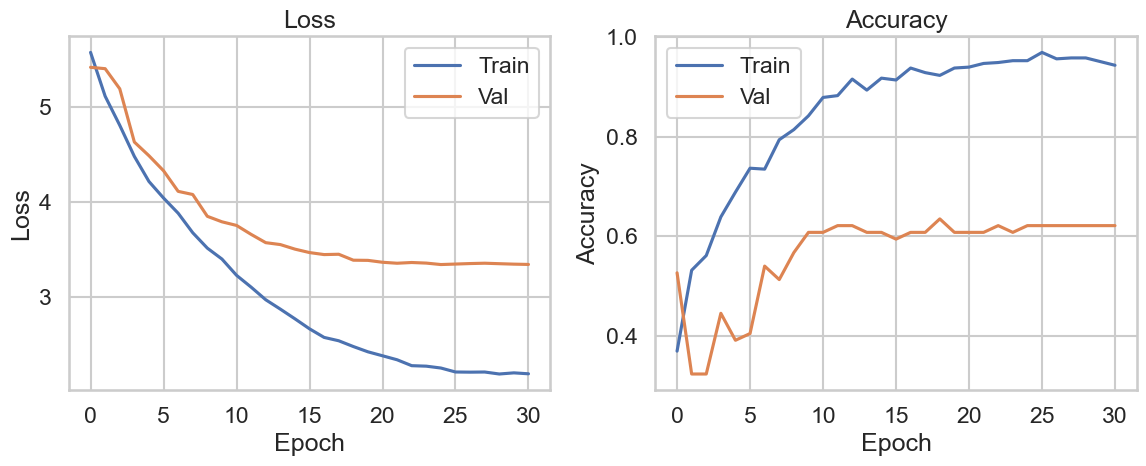

In [16]:
# Metrics & Visualizations 
sns.set(style="whitegrid", context="talk")

# Recover readable class names in the correct order (0,1,2) from your mapping
category_mapping = {'No_responder': 0, 'Average_responder': 1, 'High_responder': 2}
inv_map = {v: k for k, v in category_mapping.items()}
class_names = [inv_map[i] for i in range(len(inv_map))]  # ['No_responder','Average_responder','High_responder']

# ---- 5A) Training curves (loss & accuracy) ----
hist_df = pd.DataFrame(history.history)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
# Loss
ax[0].plot(hist_df['loss'], label='Train')
if 'val_loss' in hist_df:
    ax[0].plot(hist_df['val_loss'], label='Val')
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].legend()

# Accuracy
if 'accuracy' in hist_df:
    ax[1].plot(hist_df['accuracy'], label='Train')
if 'val_accuracy' in hist_df:
    ax[1].plot(hist_df['val_accuracy'], label='Val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('Accuracy')
ax[1].legend()
plt.tight_layout()
plt.show()


=== Validation Metrics ===
Accuracy:            0.554
Macro-F1:            0.424
Balanced Accuracy:   0.457
Macro ROC-AUC (OVR): 0.553
MCC (multi-class):   0.112

Classification report:
                   precision    recall  f1-score   support

     No_responder      0.214     0.231     0.222        13
Average_responder      0.739     0.642     0.687        53
   High_responder      0.286     0.500     0.364         8

         accuracy                          0.554        74
        macro avg      0.413     0.457     0.424        74
     weighted avg      0.598     0.554     0.570        74

OvR MCC per class:  No_responder=0.049, Average_responder=0.065, High_responder=0.276


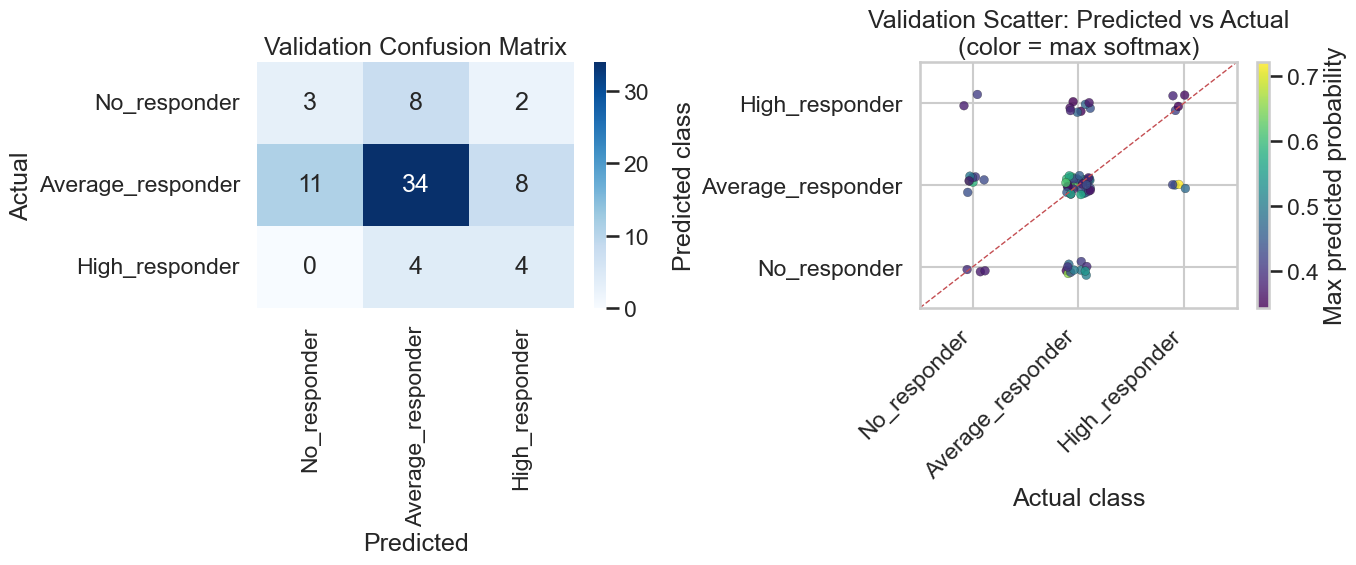

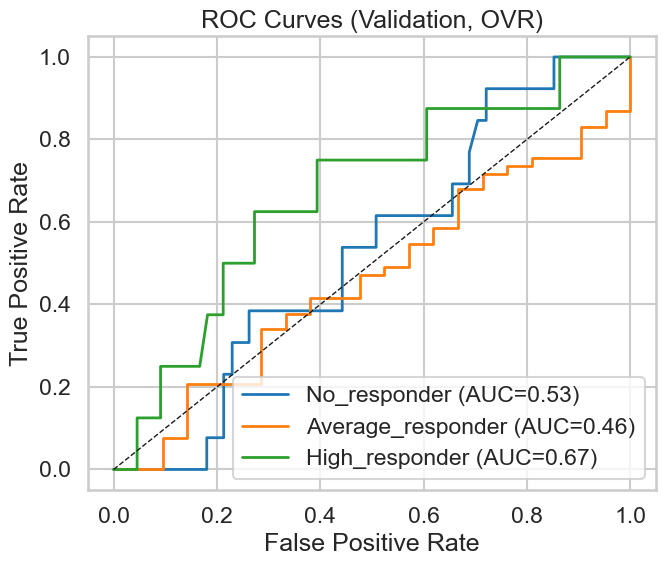

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_19780\1958734790.py:108: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\chidimmpe\AppData\Local\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


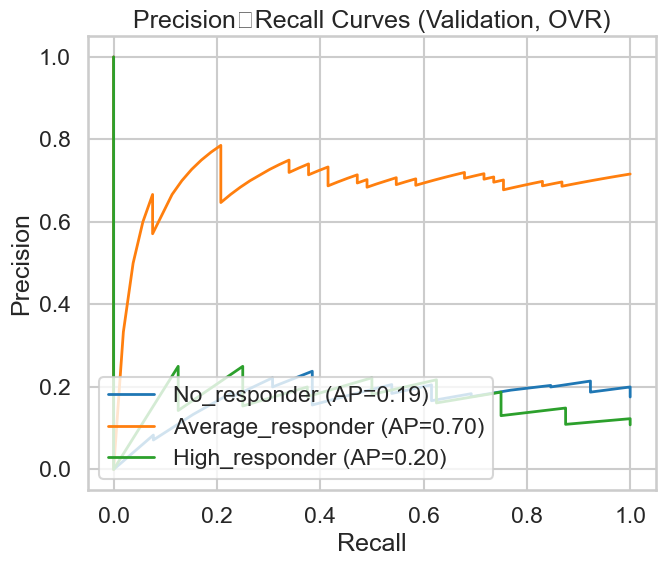


=== Test Metrics ===
Accuracy:            0.613
Macro-F1:            0.416
Balanced Accuracy:   0.417
Macro ROC-AUC (OVR): 0.528
MCC (multi-class):   0.153

Classification report:
                   precision    recall  f1-score   support

     No_responder      0.278     0.294     0.286        17
Average_responder      0.769     0.758     0.763        66
   High_responder      0.200     0.200     0.200        10

         accuracy                          0.613        93
        macro avg      0.416     0.417     0.416        93
     weighted avg      0.618     0.613     0.615        93

OvR MCC per class:  No_responder=0.120, Average_responder=0.200, High_responder=0.104


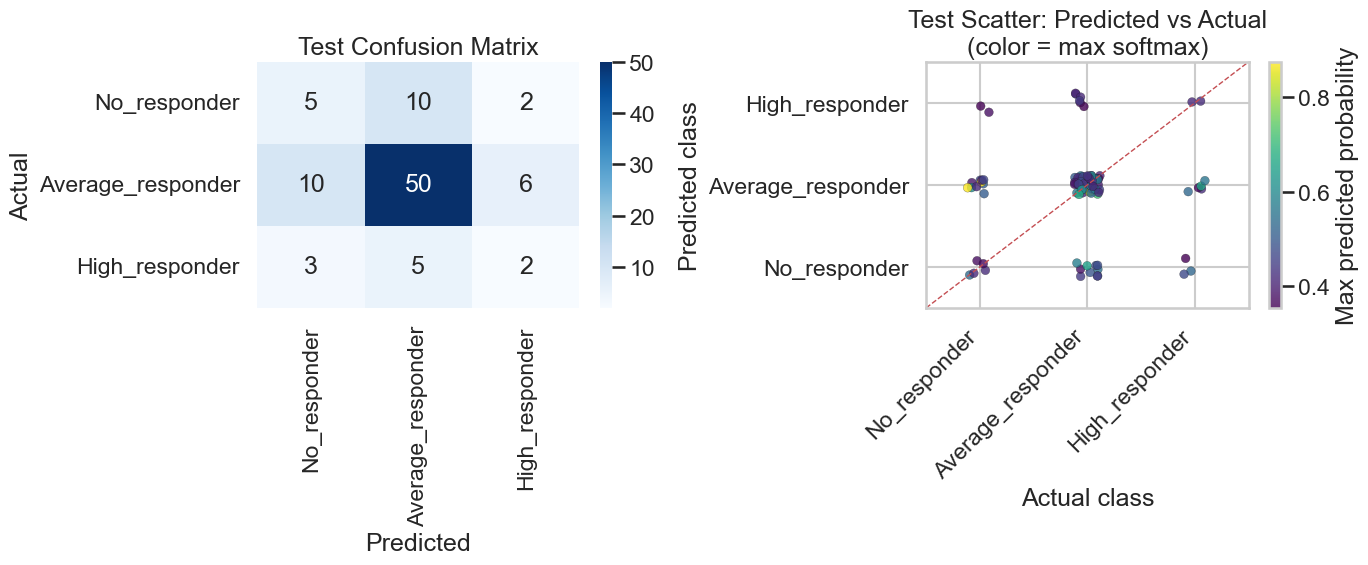

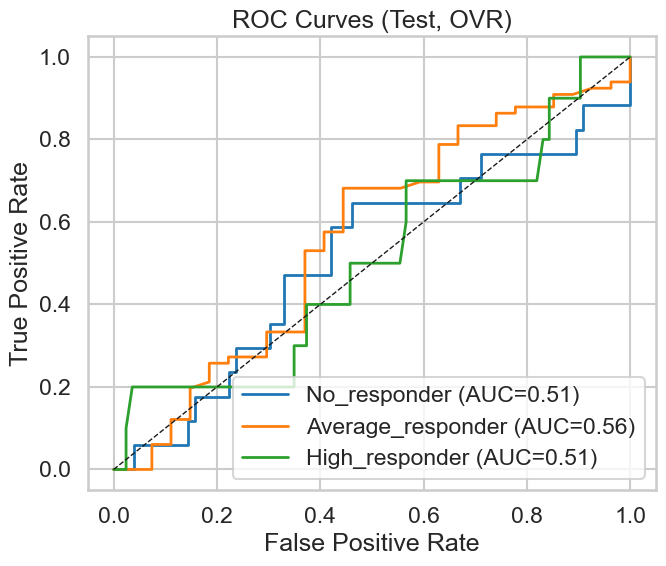

C:\Users\chidimmpe\AppData\Local\Temp\ipykernel_19780\1958734790.py:108: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\chidimmpe\AppData\Local\anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


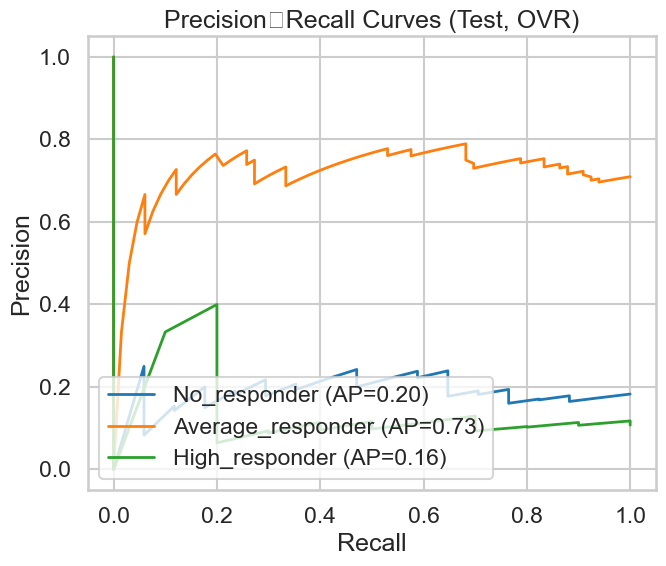

In [17]:
# ---- 5B) Run on Validation ----
evaluate_and_visualize_split("Validation", X_val_scaled, y_val, class_names, plot_roc_pr=True, save_figs=False)

# ---- 5C) Run on Test (if defined) ----
evaluate_and_visualize_split("Test", X_test_scaled, y_test, class_names, plot_roc_pr=True, save_figs=False)


In [24]:
feature_names = list(X.columns)  # from your original DataFrame
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_val_df   = pd.DataFrame(X_val_scaled,   columns=feature_names)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=feature_names)

class_names = ["No_responder", "Average_responder", "High_responder"]  # your mapping order: 0,1,2
feature_names

['age',
 'BMI',
 'sequencing_depth',
 'volume',
 'TSPAN6',
 'DPM1',
 'SCYL3',
 'CFH',
 'FUCA2',
 'GCLC',
 'NFYA',
 'NIPAL3',
 'LAS1L',
 'ENPP4',
 'ANKIB1',
 'CYP51A1',
 'KRIT1',
 'RAD52',
 'LAP3',
 'CD99',
 'CD99.1',
 'CD99.2',
 'CD99.3',
 'CD99.4',
 'CD99.5',
 'CD99.6',
 'CD99.7',
 'CD99.8',
 'CD99.9',
 'CD99.10',
 'CD99.11',
 'CD99.12',
 'CD99.13',
 'CD99.14',
 'CD99.15',
 'LASP1',
 'SNX11',
 'M6PR',
 'KLHL13',
 'DBNDD1',
 'ALS2',
 'CASP10',
 'CFLAR',
 'TFPI',
 'NDUFAF7',
 'RBM5',
 'SLC7A2',
 'ARF5',
 'SARM1',
 'POLDIP2',
 'PLXND1',
 'AK2',
 'CD38',
 'FKBP4',
 'KDM1A',
 'RBM6',
 'RECQL',
 'VPS50',
 'HSPB6',
 'NDUFAB1',
 'PDK4',
 'ARX',
 'SLC25A13',
 'ST7',
 'CDC27',
 'HCCS',
 'DVL2',
 'UPF1',
 'SKAP2',
 'SLC25A5',
 'HOXA11',
 'POLR2J',
 'DHX33',
 'MEOX1',
 'LIG3',
 'RPAP3',
 'CIAPIN1',
 'SPPL2B',
 'ATOSB',
 'COPZ2',
 'PRKAR2B',
 'MSL3',
 'CREBBP',
 'TSPOAP1',
 'GCFC2',
 'CROT',
 'ABCB4',
 'KMT2E',
 'IBTK',
 'ZNF195',
 'MYCBP2',
 'FBXL3',
 'PDK2',
 'ITGA3',
 'ZFX',
 'LAMP2',
 'ASB4',


In [64]:
# Small, representative background for SHAP's reference expectation
#bg = shap.sample(X_train_df, 200, random_state=42)  # or X_train_df.sample(200, random_state=42)

# A masker tells SHAP how to integrate out missing features; Independent is standard for tabular
#masker = shap.maskers.Independent(bg)

# Create the explainer; output_names makes per-class plots readable
#shap_explainer = shap.Explainer(best_model, masker=masker, output_names=class_names)


In [23]:
# Assume X_train_scaled is your training data (scaled), and feature_names is a list of column names
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_scaled,
    feature_names=feature_names,
    class_names=["No_responder", "Average_responder", "High_responder"],
    mode='classification',
    discretize_continuous=True
)



In [111]:
y_train.iloc[3]

1

In [20]:
def predict_fn(x):
    return best_model.predict(x)



In [21]:
i = 3  # index of the sample to explain
exp = explainer.explain_instance(
    data_row=X_val_scaled[i],
    predict_fn=predict_fn,
    num_features=10,  # top 10 features
    top_labels=1      # explain the top predicted class
)


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


In [22]:
# Show explanation in notebook
exp.show_in_notebook(show_table=True)

# Or save to HTML
#exp.save_to_file('lime_explanation_sample5.html')


In [96]:
#exp = explainer.explain_instance(...)
print(exp.as_list(exp))  # prints feature contributions


KeyError: <lime.explanation.Explanation object at 0x000001549F68B8F0>

In [81]:

def return_weights(exp):
    """Extract weights from LIME explanation object for regression"""
    # Get the explanation map
    exp_map = exp.as_map()
    # Handle the case where the key might not be None
    key = list(exp_map.keys())[0] # Get the first and only key
    exp_list = exp_map[key]
    exp_list = sorted(exp_list, key=lambda x: x[0])# Sort by feature index
    exp_weight = [x[1] for x in exp_list] # extract weight
    
    return exp_weight, [x[0] for x in exp_list] # return weight and feature indices

In [82]:
weights = []
feature_indices = []
#  iterate over all test data
for x in X_val_scaled[0:179]:
    #Get explanation
    exp = explainer.explain_instance(x,
                                    best_model.predict,
                                    num_features= 20
                                    )

    # get weights
    exp_weight, indices = return_weights(exp)
    weights.append(exp_weight)
    feature_indices.append(indices)



# Use the first explanation's feature indices to get column names
first_indices = feature_indices[0]
columns = [X_val.columns[i] for i in first_indices]

# Create dataframe

lime_weights = pd.DataFrame(data=weights, columns=columns)

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
157/157 ━━━━━━━━

Text(0.5, 0, 'Mean |Weight|')

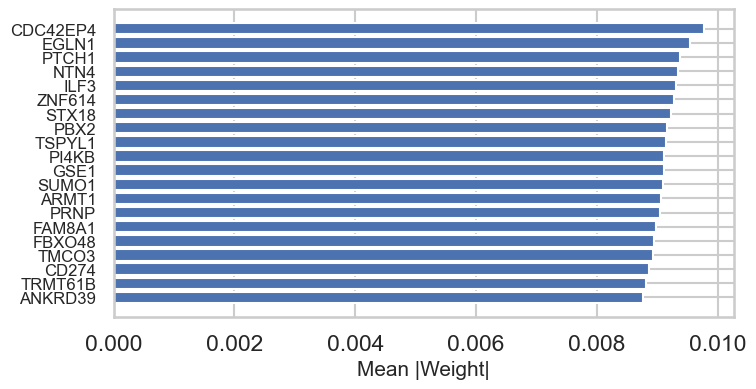

In [83]:
# geta absolute mean of LIME weights
abs_mean = lime_weights.abs().mean(axis = 0)
abs_mean = pd.DataFrame(data={"feature" : abs_mean.index, "abs_mean" : abs_mean})
abs_mean = abs_mean.sort_values("abs_mean")

# plot the mean
fig, ax = plt.subplots(nrows = 1, ncols = 1, figsize = (8,4))
y_ticks = range(len(abs_mean))
y_labels = abs_mean.feature
plt.barh(y = y_ticks, width = abs_mean.abs_mean,)
plt.yticks(ticks = y_ticks, labels = y_labels, size = 12)
plt.xlabel("Mean |Weight|", size = 15)

In [85]:


# Create LIME explainer
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_val_scaled,
    feature_names=feature_names,
    class_names=class_names,
    mode='classification',
    discretize_continuous=True
)

# Define prediction function for LIME
def predict_fn(x):
    return best_model.predict(x)

# Choose multiple samples to explain
sample_indices = [1, 2, 3, 5, 12, 27]  # replace with any indices you want to interpret

# Explain each sample
for i in sample_indices:
    exp = explainer.explain_instance(
        data_row=X_val_scaled[i],
        predict_fn=predict_fn,
        num_features=10,     # top 10 features
        top_labels=1         # explain the top predicted class
    )
    
    print(f"\nLIME Explanation for Sample {i} (True label: {class_names[y_val[i]]})")
    exp.show_in_notebook(show_table=True)

    # Optional: Save to HTML
    #exp.save_to_file(f'lime_explanation_sample_{i}.html')


157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


KeyError: 1


=== Validation Metrics ===
Accuracy:            0.649
Macro-F1:            0.512
Balanced Accuracy:   0.505
Macro ROC-AUC (OVR): 0.703
MCC (multi-class):   0.220

Classification report:
                   precision    recall  f1-score   support

     No_responder      0.312     0.385     0.345        13
Average_responder      0.769     0.755     0.762        53
   High_responder      0.500     0.375     0.429         8

         accuracy                          0.649        74
        macro avg      0.527     0.505     0.512        74
     weighted avg      0.660     0.649     0.653        74

OvR MCC per class:  No_responder=0.189, Average_responder=0.181, High_responder=0.375


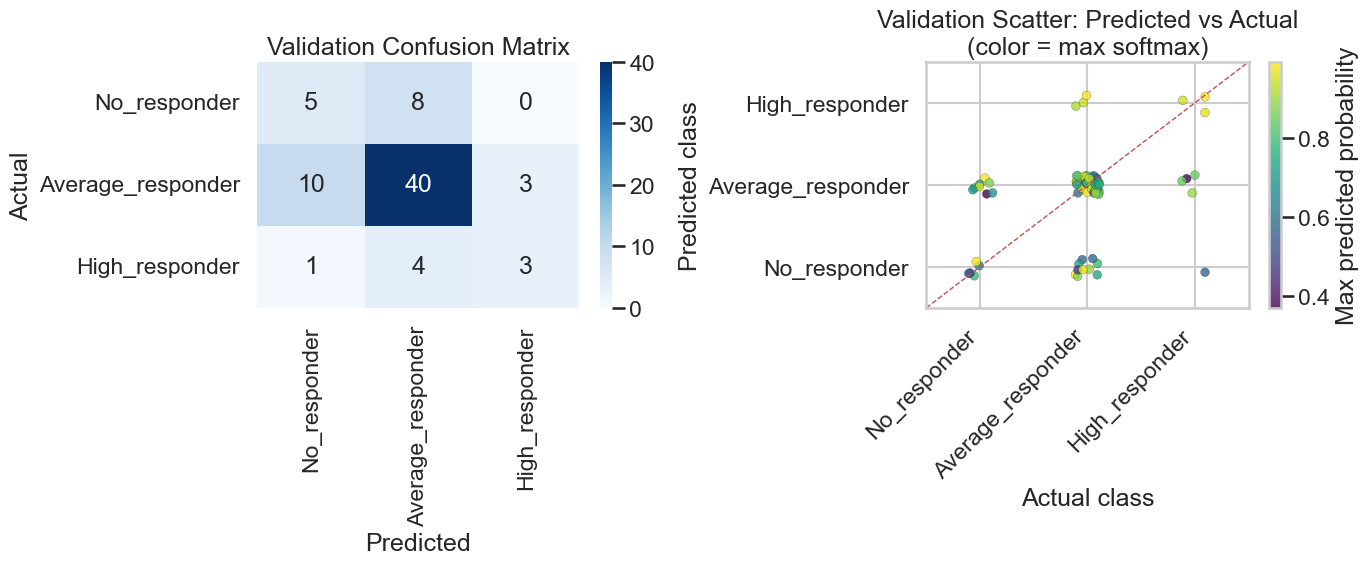

In [60]:
# Example: explain only "High_responder" (class 2) on Validation, top-3 confident cases
_ = evaluate_and_visualize_split(
    name="Validation",
    X_split=X_val_scaled, y_split=y_val,
    class_names=["No_responder","Average_responder","High_responder"],
    feature_names=[c for c in df.columns if c not in ["seq_sample_id", "category"]],
    plot_roc_pr=False, save_figs=False,
    compute_shap=True, shap_explainer=shap_explainer,
    shap_sample_n=250, shap_classes=[2], shap_local_topk=3
)


In [61]:
# Explain the validation set (use test set analogously)
shap_vals_val = shap_explainer(X_val_df.iloc[:50])  # shap_vals_val.values has shape (n_samples, n_features, n_classes)

# Optional: explain test set
# shap_vals_test = explainer(X_test_df)


ValueError: max_evals=500 is too low for the Permutation explainer, it must be at least 2 * num_features + 1 = 22463!

In [50]:
# For class index k (0=No_responder, 1=Average_responder, 2=High_responder)
k = 2  # e.g., "High_responder"
shap.plots.beeswarm(shap_vals_val[:, :, k], max_display=20, show=True)
plt.title(f"Beeswarm — {class_names[k]}"); plt.show()


NameError: name 'shap_vals_val' is not defined

In [ ]:
i = 0  # row index in X_val_df
k = 2  # class to explain (High_responder)

# Waterfall: additive contribution from base value to prediction for class k
shap.plots.waterfall(shap_vals_val[i, :, k], max_display=15)
plt.title(f"Waterfall — sample {i}, class {class_names[k]}")
plt.show()

# Force plot (inline in Jupyter; for static image, use matplotlib fallback)
shap.plots.force(shap_vals_val[i, :, k])


In [ ]:
i = 0
for k in range(len(class_names)):
    shap.plots.waterfall(shap_vals_val[i, :, k], max_display=12)
    plt.title(f"Sample {i} — class {class_names[k]}")
    plt.show()


In [ ]:
k = 2
shap.plots.heatmap(shap_vals_val[:, :, k], max_display=20)
plt.title(f"Heatmap — per-sample attributions for {class_names[k]}")
plt.show()


In [ ]:
# Explain logits instead of probabilities
# Build a logits model that shares weights but returns pre-softmax (logits)
# If your final layer is Dense(num_classes, activation='softmax'), we can reconstruct logits model:
# Note: easiest is to clone architecture and load weights, then change final activation to linear.


# Get last dense layer without activation trick by reusing weights
# (Here we rebuild a new model; adjust if your architecture differs)
inp = model.input
# Everything up to the last Dense:
pre_last = model.layers[-2].output
# Recreate final Dense layer with same weights but linear activation
last_dense = model.layers[-1]
logits = tf.keras.layers.Dense(
    last_dense.units, activation=None, use_bias=True,
    name="logits", kernel_initializer=lambda shape, dtype=None: last_dense.get_weights()[0],
    bias_initializer=lambda shape, dtype=None: last_dense.get_weights()[1]
)(pre_last)

logits_model = Model(inputs=inp, outputs=logits)

# Now create a SHAP explainer on logits_model; optionally set link to identity
explainer_logits = shap.Explainer(logits_model, masker=masker, output_names=class_names)
shap_vals_val_logits = explainer_logits(X_val_df)


In [ ]:
# Save to disk ( numpy )
np.savez_compressed(
    "shap_val_values.npz",
    values=shap_vals_val.values,
    base_values=shap_vals_val.base_values,
    feature_names=np.array(feature_names, dtype=object),
    class_names=np.array(class_names, dtype=object)
)


In [63]:
#If shap.Explainer(model, ...) has compatibility issues, use a predict function and KernelExplainer:
def predict_proba_fn(x):
    # x is np.array (n, F)
    return best_model.predict(x, verbose=0)  # returns (n, C) probabilities

bg_small = shap.sample(X_train_df, 100, random_state=42)  # keep small for speed
kernel_explainer = shap.KernelExplainer(predict_proba_fn, bg_small, link="identity")

# Explain a small batch (KernelExplainer is expensive)
X_val_small = X_val_df.sample(200, random_state=42)
shap_vals_kernel = kernel_explainer.shap_values(X_val_small, nsamples="auto")  
# Returns a list of length C, each (n_small, F)

# Plot per class:
k = 2
shap.summary_plot(shap_vals_kernel[k], X_val_small, plot_type="bar", class_names=class_names)


ValueError: Cannot take a larger sample than population when 'replace=False'

In [17]:
# Feature names (nice plots if X is a DataFrame)
feature_names = X.columns.tolist() if hasattr(X, 'columns') else [f"f{i}" for i in range(X_train_sm.shape[1])]

# Background/sample sets
rng = np.random.default_rng(42)
bg_idx  = rng.choice(X_train_sm.shape[0], size=min(200, X_train_sm.shape[0]), replace=False)
val_idx = rng.choice(X_val_scaled.shape[0], size=min(500, X_val_scaled.shape[0]), replace=False)
background   = X_train_sm[bg_idx]
X_val_sample = X_val_scaled[val_idx]

# Probability predictor
predict_fn = lambda x: model.predict(x, verbose=0)

# Try Deep/Gradient, else fallback
try:
    explainer = shap.DeepExplainer(model, background)
    _ = explainer.shap_values(background[:1])
    shap_values = explainer(X_val_sample)
except Exception:
    try:
        explainer = shap.GradientExplainer((model, model.layers[0].input), background)
        shap_values = explainer(X_val_sample)
    except Exception:
        explainer = shap.Explainer(predict_fn, background)
        shap_values = explainer(X_val_sample)

# Multiclass: loop classes
n_classes = 3
for c in range(n_classes):
    try:
        sv = shap_values[..., c]  # new API
    except Exception:
        sv = shap_values[c]       # old API

    shap.summary_plot(sv, X_val_sample, feature_names=feature_names, show=False)
    plt.title(f"SHAP Summary – Class {c}")
    plt.savefig(f"shap_summary_class{c}.png", dpi=200, bbox_inches="tight"); plt.close()

    shap.summary_plot(sv, X_val_sample, feature_names=feature_names, plot_type="bar", show=False)
    plt.title(f"SHAP Global Importance (Bar) – Class {c}")
    plt.savefig(f"shap_bar_class{c}.png", dpi=200, bbox_inches="tight"); plt.close()

# Local explanation for a sample
i = 0
try:
    shap.plots.waterfall(shap_values[i], show=False)
    plt.title("SHAP Waterfall – Sample 0")
    plt.savefig("shap_waterfall_sample0.png", dpi=200, bbox_inches="tight"); plt.close()
except Exception:
    pass

# Assuming you already computed shap_values on a val sample
minor_idx = np.where(y_val == 2)[0]  # e.g., class 2 as minority
minor_idx = minor_idx[:min(200, len(minor_idx))]

# For multiclass, pick the SHAP values for class 2
sv_c2 = shap_values[..., 2] if hasattr(shap_values, 'values') else shap_values[2]

shap.summary_plot(sv_c2[minor_idx], X_val_scaled[minor_idx],
                  feature_names=getattr(X, 'columns', None), show=True)


ValueError: max_evals=500 is too low for the Permutation explainer, it must be at least 2 * num_features + 1 = 22463!

In [16]:


def shap_explain(model, X_train_scaled, X_val_scaled, feature_names=None, max_bg=200, max_val=500):
    rng = np.random.default_rng(42)
    bg_idx  = rng.choice(X_train_scaled.shape[0], size=min(max_bg, X_train_scaled.shape[0]), replace=False)
    val_idx = rng.choice(X_val_scaled.shape[0],   size=min(max_val, X_val_scaled.shape[0]), replace=False)
    background   = X_train_scaled[bg_idx]
    X_val_sample = X_val_scaled[val_idx]

    def predict_fn(x): return model.predict(x, verbose=0)

    try:
        explainer = shap.DeepExplainer(model, background)
        _ = explainer.shap_values(background[:1])
        shap_values = explainer(X_val_sample)
    except Exception:
        try:
            explainer = shap.GradientExplainer((model, model.layers[0].input), background)
            shap_values = explainer(X_val_sample)
        except Exception:
            explainer = shap.Explainer(predict_fn, background)
            shap_values = explainer(X_val_sample)

    n_classes = model.output_shape[-1]
    for c in range(n_classes):
        try:
            sv = shap_values[..., c]  # new API
        except Exception:
            sv = shap_values[c]       # old API

        shap.summary_plot(sv, X_val_sample, feature_names=feature_names, show=False)
        plt.title(f"SHAP Summary – Class {c}"); plt.tight_layout()
        plt.savefig(f"shap_summary_class{c}.png", dpi=200, bbox_inches="tight"); plt.close()

        shap.summary_plot(sv, X_val_sample, feature_names=feature_names, plot_type="bar", show=False)
        plt.title(f"SHAP Global Importance (Bar) – Class {c}"); plt.tight_layout()
        plt.savefig(f"shap_bar_class{c}.png", dpi=200, bbox_inches="tight"); plt.close()

    # Local explanation example
    try:
        shap.plots.waterfall(shap_values[0], show=False)
        plt.title("SHAP Waterfall – Sample 0"); plt.tight_layout()
        plt.savefig("shap_waterfall_sample0.png", dpi=200, bbox_inches="tight"); plt.close()
    except Exception:
        pass

feature_names = list(X.columns) if hasattr(X, "columns") else [f"f{i}" for i in range(X_train_scaled.shape[1])]
shap_explain(model, X_train_scaled, X_val_scaled, feature_names)


C:\Users\chidimmpe\AppData\Local\anaconda\Lib\site-packages\shap\explainers\_deep\deep_tf.py:99: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn("Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.")
C:\Users\chidimmpe\AppData\Local\anaconda\Lib\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor
Received: inputs=['Tensor(shape=(200, 11231))']
  warnings.warn(msg)


ValueError: max_evals=500 is too low for the Permutation explainer, it must be at least 2 * num_features + 1 = 22463!